<a href="https://colab.research.google.com/github/reinaldo-agp/synthetic-data-gan/blob/main/gan_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/Follow-up_Records.csv')

In [ ]:
print(df.head())

   patient_id  visit_date  age_years  weight_kg   bmi  systolic_bp_mmHg  \
0  P-2025-001  2024-02-15         52       83.7  28.3               138   
1  P-2025-001  2024-03-15         52       83.4  28.2               147   
2  P-2025-001  2024-04-15         52       83.1  28.1               140   
3  P-2025-001  2024-05-15         52       83.0  28.1               136   
4  P-2025-001  2024-06-15         52       82.6  27.9               133   

   diastolic_bp_mmHg  heart_rate_bpm  body_temp_C  fasting_glucose_mg_dL  ...  \
0                 86              80         36.8                    137  ...   
1                 89              80         37.0                    140  ...   
2                 84              76         36.8                    122  ...   
3                 88              77         36.8                    112  ...   
4                 88              78         36.8                    101  ...   

   diet_quality_score_0_100  sleep_hours  exercise_sessions_pe

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(sparse_output=False)
cat_encoded = encoder.fit_transform(df[cat_cols])

scaler = MinMaxScaler(feature_range=(-1, 1))
num_scaled = scaler.fit_transform(df[num_cols])

# combine processed data
data_processed = np.hstack((num_scaled, cat_encoded))

In [ ]:
import torch
import torch.nn as nn

data_dim = data_processed.shape[1]  # total features
latent_dim = 64  # size of random noise input

# generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, data_dim),
            nn.Tanh()  # output in range [-1, 1]
        )
    def forward(self, z):
        return self.model(z)

# discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()  # probability of real/fake
        )
    def forward(self, x):
        return self.model(x)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# convert data to PyTorch tensors
real_data = torch.tensor(data_processed, dtype=torch.float32)
dataset = TensorDataset(real_data)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# initialize models
generator = Generator()
discriminator = Discriminator()

# optimizers
lr = 0.0002
optim_G = torch.optim.Adam(generator.parameters(), lr=lr)
optim_D = torch.optim.Adam(discriminator.parameters(), lr=lr)

# loss
criterion = nn.BCELoss()

epochs = 2000
for epoch in range(epochs):
    for real_batch, in loader:
        batch_size = real_batch.size(0)

        # labels for real and fake data
        real_labels = torch.ones((batch_size, 1))
        fake_labels = torch.zeros((batch_size, 1))

        # train discriminator
        z = torch.randn(batch_size, latent_dim)
        fake_data = generator(z)

        real_loss = criterion(discriminator(real_batch), real_labels)
        fake_loss = criterion(discriminator(fake_data.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2

        optim_D.zero_grad()
        d_loss.backward()
        optim_D.step()

        # train generator
        z = torch.randn(batch_size, latent_dim)
        fake_data = generator(z)
        g_loss = criterion(discriminator(fake_data), real_labels)  # want fake to be real

        optim_G.zero_grad()
        g_loss.backward()
        optim_G.step()

    if epoch % 200 == 0:
        print(f"Epoch [{epoch}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

Epoch [0/2000]  D_loss: 0.6809  G_loss: 0.7057
Epoch [200/2000]  D_loss: 0.3131  G_loss: 1.5952
Epoch [400/2000]  D_loss: 0.6014  G_loss: 1.6070
Epoch [600/2000]  D_loss: 0.1124  G_loss: 1.7342
Epoch [800/2000]  D_loss: 0.0902  G_loss: 1.7995
Epoch [1000/2000]  D_loss: 0.3565  G_loss: 1.5798
Epoch [1200/2000]  D_loss: 0.1093  G_loss: 2.6058
Epoch [1400/2000]  D_loss: 0.0750  G_loss: 2.1753
Epoch [1600/2000]  D_loss: 0.0669  G_loss: 2.8158
Epoch [1800/2000]  D_loss: 0.1262  G_loss: 2.6918


In [ ]:
# generate new synthetic data
z = torch.randn(10, latent_dim)  # 10 synthetic samples
synthetic_data_scaled = generator(z).detach().numpy()

# inverse transform
num_synthetic = scaler.inverse_transform(synthetic_data_scaled[:, :len(num_cols)])
cat_synthetic = encoder.inverse_transform(synthetic_data_scaled[:, len(num_cols):])

# combine into dataframe
synthetic_df = pd.DataFrame(num_synthetic, columns=num_cols)
synthetic_df[cat_cols] = cat_synthetic

print(synthetic_df)

   age_years  weight_kg        bmi  systolic_bp_mmHg  diastolic_bp_mmHg  \
0  52.000599  83.096565  27.988989        139.253372          84.347237   
1  52.999981  80.785728  27.304543        120.462128          74.875740   
2  52.136898  82.246758  27.708725        131.473389          83.315315   
3  52.000011  83.196068  27.952724        137.339462          87.722473   
4  52.850124  81.585785  27.509140        127.574532          81.354340   
5  52.000000  83.662140  28.222118        142.836441          89.027306   
6  52.000259  83.252869  28.060123        138.904404          85.027443   
7  52.000000  83.282196  28.109884        140.452728          87.141495   
8  52.000000  83.686096  28.245958        142.595200          89.784523   
9  52.058971  81.456482  27.359688        125.597198          84.340309   

   heart_rate_bpm  body_temp_C  fasting_glucose_mg_dL  \
0       76.628448    36.809883             112.723892   
1       74.060226    36.700981              91.566498   
2  

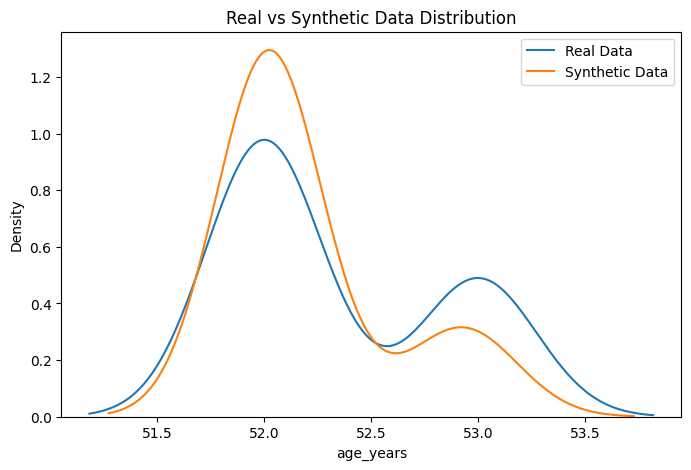

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# comparar distribución real vs sintética
plt.figure(figsize=(8,5))

sns.kdeplot(df[num_cols[0]], label="Real Data")
sns.kdeplot(synthetic_df[num_cols[0]], label="Synthetic Data")

plt.legend()
plt.title("Real vs Synthetic Data Distribution")
plt.show()